iter 0: ll=323222.20
iter 1: ll=568158.62
iter 2: ll=627668.02
iter 3: ll=650493.20
iter 4: ll=665266.01
iter 5: ll=676576.65
iter 6: ll=685443.61
iter 7: ll=692373.47
iter 8: ll=697735.14
iter 9: ll=701787.09
iter 10: ll=704702.12
iter 11: ll=706628.75
iter 12: ll=707745.06
iter 13: ll=708261.43
iter 14: ll=708390.28
iter 15: ll=708309.02
iter 16: ll=708141.38
iter 17: ll=707959.76
iter 18: ll=707798.79
iter 19: ll=707670.09
iter 20: ll=707573.60
iter 21: ll=707504.45
iter 22: ll=707456.66
iter 23: ll=707424.71
iter 24: ll=707404.13
iter 25: ll=707391.48
iter 26: ll=707384.24
iter 27: ll=707380.63
iter 28: ll=707379.41
iter 29: ll=707379.70


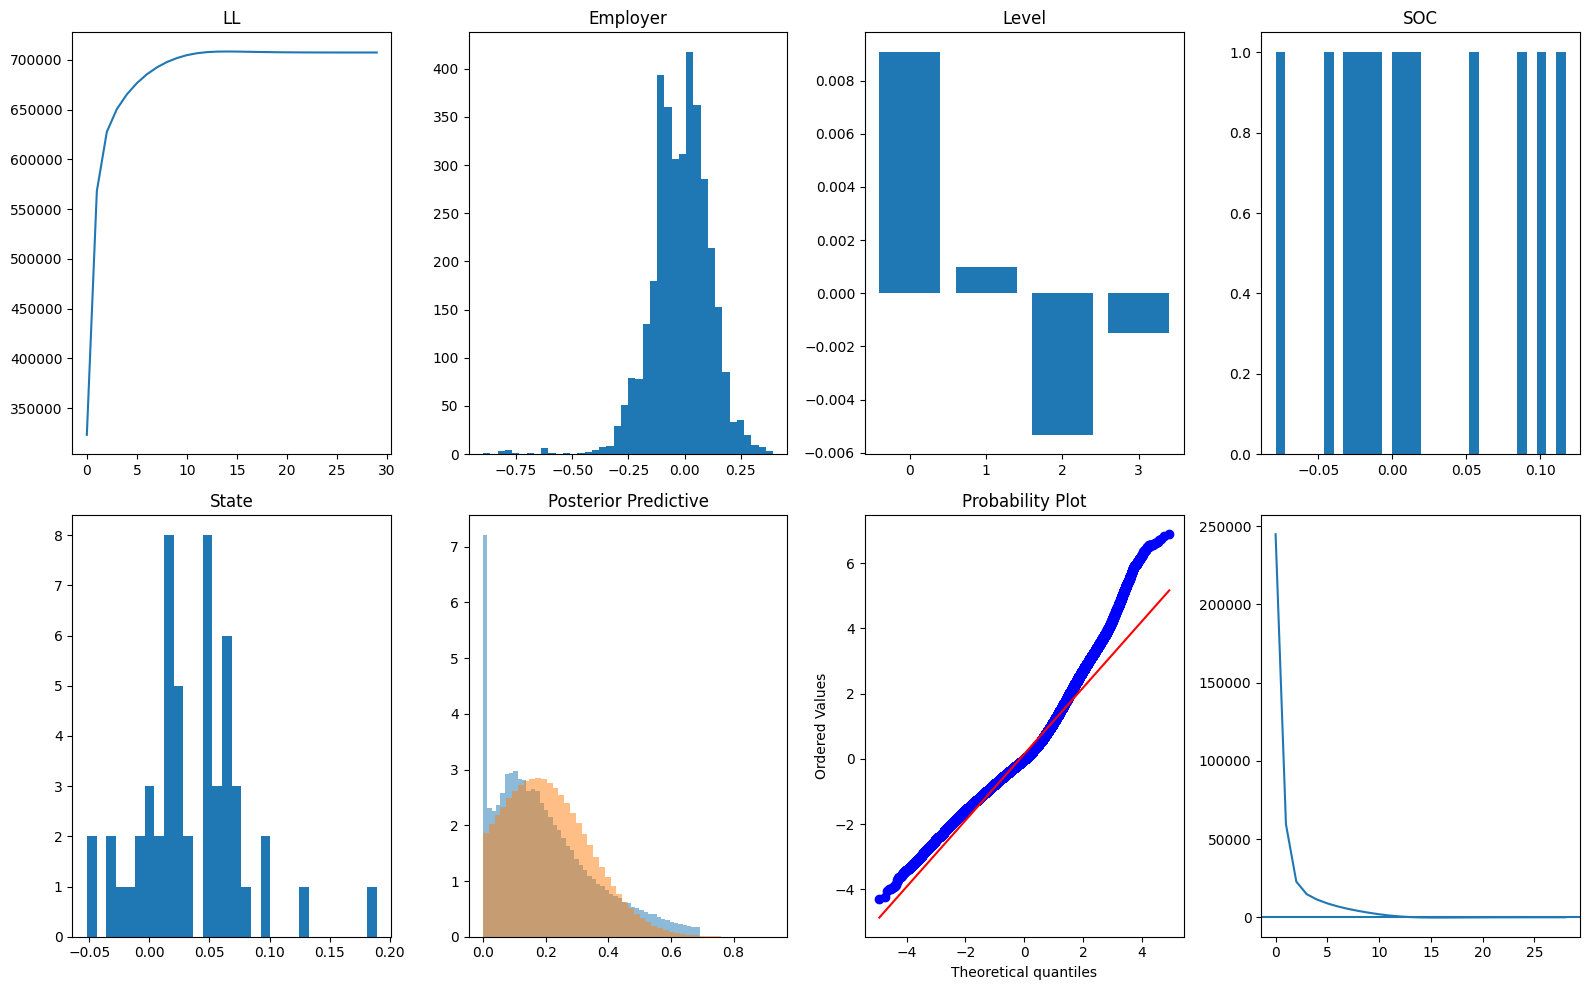

In [9]:
# =========================
# FINAL CLEAN EM (WARMUP + FREEZE VARIANCES)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

EPS = 1e-6
MAX_VAL = 1e6

# =========================
# DATA PREP
# =========================

def prepare_data(df):

    df = df.copy()

    df["SOC_2DIGIT"] = df["SOC_CODE"].astype(str).str[:2]
    soc_counts = df["SOC_2DIGIT"].value_counts()
    df["SOC_F"] = df["SOC_2DIGIT"].where(
        df["SOC_2DIGIT"].isin(soc_counts[soc_counts >= 100].index),
        "OTHER"
    )

    state_counts = df["WORKSITE_STATE"].value_counts()
    df["STATE_F"] = df["WORKSITE_STATE"].where(
        df["WORKSITE_STATE"].isin(state_counts[state_counts >= 100].index),
        "OTHER"
    )

    S = pd.Categorical(df["SOC_F"]).codes
    ST = pd.Categorical(df["STATE_F"]).codes
    E = pd.Categorical(df["EMPLOYER_NAME_CLEAN"]).codes

    level_map = {"I":0,"II":1,"III":2,"IV":3}
    L = df["WAGE_LEVEL_CLEAN"].map(level_map).values

    y = np.maximum(np.log(df["wage_ratio"].values), 0)
    censored = (y == 0)

    return {
        "y": y,
        "censored": censored,
        "L": L,
        "E": E,
        "S": S,
        "ST": ST,
        "K": 4,
        "N_E": len(np.unique(E)),
        "N_S": len(np.unique(S)),
        "N_ST": len(np.unique(ST))
    }

# =========================
# E STEP
# =========================

def truncated_normal_moments(mu, sigma):

    sigma = np.maximum(sigma, EPS)
    alpha = np.clip(-mu / sigma, -10, 10)

    phi = stats.norm.pdf(alpha)
    Phi = np.clip(stats.norm.cdf(alpha), 1e-10, 1.0)

    ratio = np.clip(phi / Phi, -MAX_VAL, MAX_VAL)

    E1 = mu - sigma * ratio
    E2 = mu**2 + sigma**2 - sigma * (mu + sigma * ratio) * ratio

    return E1, E2

def e_step(y, censored, mu, sigma):

    y_star = y.copy()
    y_star2 = y**2

    if censored.any():
        E1, E2 = truncated_normal_moments(mu[censored], sigma)
        y_star[censored] = E1
        y_star2[censored] = E2

    return y_star, y_star2

# =========================
# SAFE VARIANCE UPDATES
# =========================

def update_sigma(alpha):
    return max((np.sum(alpha**2) + 0.1) / (len(alpha) + 2), 1e-4)

def update_sigma2(resid2):
    return max((np.sum(resid2) + 0.1) / (len(resid2) + 2), 1e-4)

def damp(old, new, w=0.1):
    return (1-w)*old + w*new

# =========================
# M STEP (MEANS ONLY)
# =========================

def m_step(y_star, y_star2, L, E, S, ST,
           gamma, alpha, delta, eta,
           sigma2, sigma_E2, sigma_L2, sigma_S2, sigma_ST2):

    n = len(y_star)

    lam_L = min(sigma2 / sigma_L2, MAX_VAL)
    lam_E = min(sigma2 / sigma_E2, MAX_VAL)
    lam_S = min(sigma2 / sigma_S2, MAX_VAL)
    lam_ST = min(sigma2 / sigma_ST2, MAX_VAL)

    K, N_E, N_S, N_ST = len(gamma), len(alpha), len(delta), len(eta)

    n_L = np.bincount(L, minlength=K)
    n_E = np.bincount(E, minlength=N_E)
    n_S = np.bincount(S, minlength=N_S)
    n_ST = np.bincount(ST, minlength=N_ST)

    Sy_L = np.bincount(L, weights=y_star, minlength=K)
    Sy_E = np.bincount(E, weights=y_star, minlength=N_E)
    Sy_S = np.bincount(S, weights=y_star, minlength=N_S)
    Sy_ST = np.bincount(ST, weights=y_star, minlength=N_ST)

    Sy_total = y_star.sum()

    for _ in range(30):

        beta0 = (Sy_total - (gamma[L] + alpha[E] + delta[S] + eta[ST]).sum()) / n

        gamma = (Sy_L - np.bincount(L, weights=alpha[E]+delta[S]+eta[ST], minlength=K) - n_L*beta0) / (n_L + lam_L)
        alpha = (Sy_E - np.bincount(E, weights=gamma[L]+delta[S]+eta[ST], minlength=N_E) - n_E*beta0) / (n_E + lam_E)
        delta = (Sy_S - np.bincount(S, weights=gamma[L]+alpha[E]+eta[ST], minlength=N_S) - n_S*beta0) / (n_S + lam_S)
        eta   = (Sy_ST - np.bincount(ST, weights=gamma[L]+alpha[E]+delta[S], minlength=N_ST) - n_ST*beta0) / (n_ST + lam_ST)

    mu = beta0 + gamma[L] + alpha[E] + delta[S] + eta[ST]

    resid2 = np.clip(y_star2 - 2*y_star*mu + mu**2, 0, MAX_VAL)
    sigma2 = update_sigma2(resid2)

    return beta0, gamma, alpha, delta, eta, sigma2, mu

# =========================
# LOG LIKELIHOOD
# =========================

def observed_ll(y, censored, mu, sigma):

    sigma = max(sigma, 1e-4)

    ll = 0
    if (~censored).any():
        ll += stats.norm.logpdf(y[~censored], mu[~censored], sigma).sum()

    if censored.any():
        ll += np.log(np.clip(stats.norm.cdf(0, mu[censored], sigma), 1e-10, 1)).sum()

    return ll

# =========================
# FIT MODEL
# =========================

def fit_model(data, max_iter=50):

    y, censored = data['y'], data['censored']
    L, E, S, ST = data['L'], data['E'], data['S'], data['ST']

    gamma = np.zeros(data['K'])
    alpha = np.zeros(data['N_E'])
    delta = np.zeros(data['N_S'])
    eta   = np.zeros(data['N_ST'])

    beta0 = np.mean(y)

    sigma2 = 1.0
    sigma_E2 = sigma_L2 = sigma_S2 = sigma_ST2 = 0.1

    lls = []
    history = []

    for it in range(max_iter):

        mu = beta0 + gamma[L] + alpha[E] + delta[S] + eta[ST]

        y_star, y_star2 = e_step(y, censored, mu, np.sqrt(sigma2))

        beta0, gamma, alpha, delta, eta, sigma2, mu = m_step(
            y_star, y_star2, L, E, S, ST,
            gamma, alpha, delta, eta,
            sigma2, sigma_E2, sigma_L2, sigma_S2, sigma_ST2
        )

        # 🔥 Warmup → Freeze
        if it < 10:
            sigma_E2 = damp(sigma_E2, update_sigma(alpha))
            sigma_L2 = damp(sigma_L2, update_sigma(gamma))
            sigma_S2 = damp(sigma_S2, update_sigma(delta))
            sigma_ST2 = damp(sigma_ST2, update_sigma(eta))

        ll = observed_ll(y, censored, mu, np.sqrt(sigma2))
        lls.append(ll)

        history.append({
            "sigma": np.sqrt(sigma2),
            "sigma_E": np.sqrt(sigma_E2),
            "sigma_L": np.sqrt(sigma_L2),
            "sigma_S": np.sqrt(sigma_S2),
            "sigma_ST": np.sqrt(sigma_ST2)
        })

        print(f"iter {it}: ll={ll:.2f}")

        if it > 2 and abs(lls[-1] - lls[-2]) < 1:
            break

    return {
        "beta0": beta0,
        "gamma": gamma,
        "alpha": alpha,
        "delta": delta,
        "eta": eta,
        "sigma": np.sqrt(sigma2),
        "lls": lls,
        "history": history,
        "data": data
    }

# =========================
# DIAGNOSTICS
# =========================

def plot_results(result):

    data = result["data"]
    mu = (result["beta0"]
          + result["gamma"][data["L"]]
          + result["alpha"][data["E"]]
          + result["delta"][data["S"]]
          + result["eta"][data["ST"]])

    sigma = result["sigma"]
    y = data["y"]

    fig = plt.figure(figsize=(16,10))
    gs = gridspec.GridSpec(2,4)

    plt.subplot(gs[0,0]); plt.plot(result["lls"]); plt.title("LL")
    plt.subplot(gs[0,1]); plt.hist(result["alpha"], bins=40); plt.title("Employer")
    plt.subplot(gs[0,2]); plt.bar(range(4), result["gamma"]); plt.title("Level")
    plt.subplot(gs[0,3]); plt.hist(result["delta"], bins=30); plt.title("SOC")

    plt.subplot(gs[1,0]); plt.hist(result["eta"], bins=30); plt.title("State")

    plt.subplot(gs[1,1])
    y_sim = np.maximum(np.random.normal(mu, sigma), 0)
    plt.hist(y[y>0], bins=50, density=True, alpha=0.5)
    plt.hist(y_sim[y_sim>0], bins=50, density=True, alpha=0.5)
    plt.title("Posterior Predictive")

    plt.subplot(gs[1,2])
    stats.probplot((y[y>0]-mu[y>0])/sigma, plot=plt)

    plt.subplot(gs[1,3])
    plt.plot(np.diff(result["lls"]))
    plt.axhline(0)

    plt.tight_layout()
    plt.show()

# =========================
# RUN
# =========================

if __name__ == "__main__":

    df = pd.read_parquet("../data/final_filtered.parquet")

    df = df[(df.wage_ratio < 2) & (df.wage_ratio > 0.5)]
    df = df[df["EMPLOYER_NAME_CLEAN"].map(df["EMPLOYER_NAME_CLEAN"].value_counts()) >= 100]

    data = prepare_data(df)

    result = fit_model(data)

    plot_results(result)


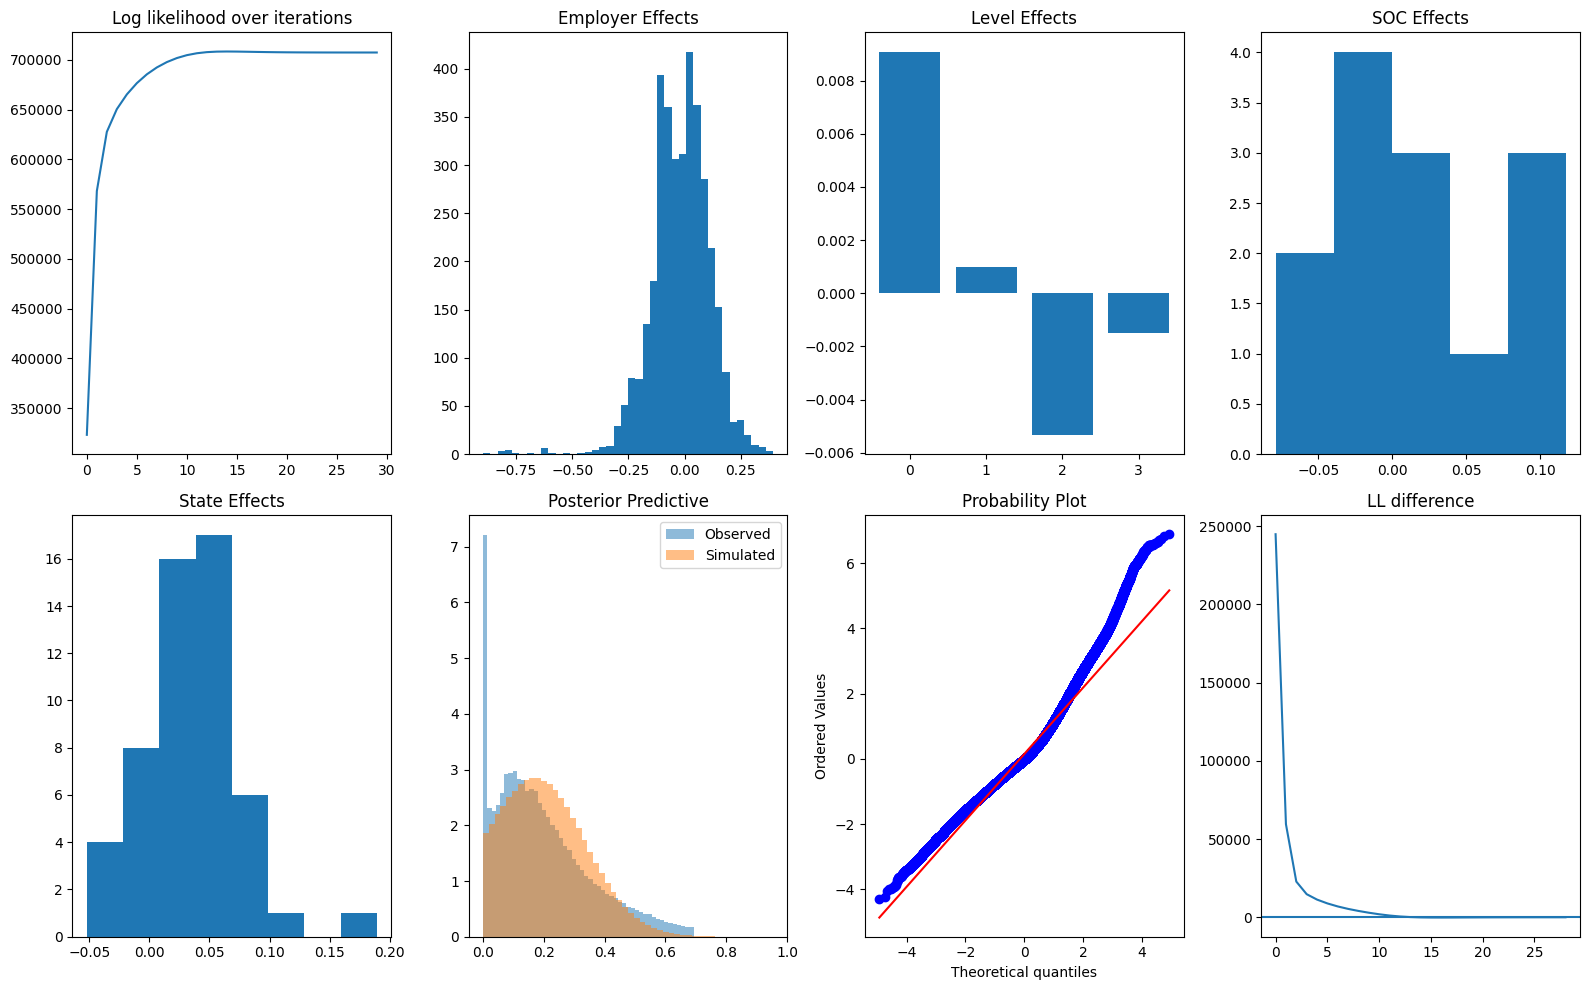

In [14]:
def plot_results(result):

    data = result["data"]
    mu = (result["beta0"]
          + result["gamma"][data["L"]]
          + result["alpha"][data["E"]]
          + result["delta"][data["S"]]
          + result["eta"][data["ST"]])

    sigma = result["sigma"]
    y = data["y"]

    fig = plt.figure(figsize=(16,10))
    gs = gridspec.GridSpec(2,4)

    plt.subplot(gs[0,0]); plt.plot(result["lls"]); plt.title("Log likelihood over iterations")
    plt.subplot(gs[0,1]); plt.hist(result["alpha"], bins=40); plt.title("Employer Effects")
    plt.subplot(gs[0,2]); plt.bar(range(4), result["gamma"]); plt.title("Level Effects")
    plt.subplot(gs[0,3]); plt.hist(result["delta"], bins=5); plt.title("SOC Effects")

    plt.subplot(gs[1,0]); plt.hist(result["eta"], bins=8); plt.title("State Effects")

    plt.subplot(gs[1,1])
    y_sim = np.maximum(np.random.normal(mu, sigma), 0)
    plt.hist(y[y>0], bins=50, density=True, alpha=0.5, label="Observed")
    plt.hist(y_sim[y_sim>0], bins=50, density=True, alpha=0.5, label="Simulated")

    plt.legend()
    plt.title("Posterior Predictive")

    plt.subplot(gs[1,2])
    stats.probplot((y[y>0]-mu[y>0])/sigma, plot=plt)

    plt.subplot(gs[1,3])
    plt.plot(np.diff(result["lls"])); plt.title("LL difference")
    plt.axhline(0)

    plt.tight_layout()
    plt.show()

plot_results(result)